Name:   Srujana Duggineni

ID:     C00313483

#### 1. Business Understanding:

Algorithm: K-Nearest Neighbors (KNN)
Dataset: Breast Cancer Dataset (from sklearn.datasets)

Objective: The goal of this study is to implement and evaluate the K-Nearest Neighbors (KNN) algorithm, both from custom and using the built-in Scikit-learn library. We will be comparing the performance of these two approaches on the Breast Cancer Dataset to determine the feasibility of using a custom implementation in real-world applications.

####  Load dataset

#### 2. Data Understanding
Dataset Used: Breast Cancer dataset from sklearn.datasets (includes features like mean radius, mean texture, mean smoothness, etc.)

Feature Description:
The dataset contains 30 numerical features that represent various measurements of the breast cancer cell nuclei.

Target:
The target variable is a binary class (0 for malignant and 1 for benign tumors).


In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_breast_cancer

# Load the Breast Cancer dataset from Scikit-learn
data = load_breast_cancer()
X,y =data.data,data.target

#### 3. Data Preperation - Data Splitting


In [2]:
# training and testing sets -
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=99)


#### 4. Modelling
Baseline Implementation (KNN from custom)

The model was trained using the training data and predictions were made using the test data.


In [3]:

### building KNN- K-Nearest Neighbors
class KNNcustom:
    def __init__(self,k=3):
        self.k = k

    def fit(self,X,y):
        self.X_train = X
        self.y_train = y

    def predict(self,X):
        predictions = []
        for x in X:
            distances = np.linalg.norm(self.X_train - x,axis=1)
            k_indices = np.argsort(distances)[:self.k]
            k_nearest_labels = self.y_train[k_indices]
            predictions.append(np.bincount(k_nearest_labels).argmax())
        return np.array(predictions)




#### 5. Evaluation



In [4]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

# Define range of K values to test
k_values = [3, 5, 10, 15]

# Use Stratified K-Fold Cross-Validation (ensures class balance in each fold)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store results
knn_results = {}

# Loop over different K values
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=cv, scoring='accuracy')  # 5-fold CV
    
    # Store mean accuracy and standard deviation
    knn_results[k] = (np.mean(scores), np.std(scores))
    print(f"K={k}: Mean Accuracy={np.mean(scores):.4f}, Std Dev={np.std(scores):.4f}")

# Find best K
best_k = max(knn_results, key=lambda k: knn_results[k][0])
print("\nAccording to lib Model")
print(f"\nBest K according to Cross-Validation: {best_k}")



K=3: Mean Accuracy=0.9275, Std Dev=0.0204
K=5: Mean Accuracy=0.9319, Std Dev=0.0176
K=10: Mean Accuracy=0.9363, Std Dev=0.0189
K=15: Mean Accuracy=0.9231, Std Dev=0.0155

According to lib Model

Best K according to Cross-Validation: 10


In [5]:
print("\nAccording to Custom  model")


#  the custom KNN model
knn_custom = KNNcustom(k=3)
knn_custom.fit(X_train,y_train)
y_pred_custom = knn_custom.predict(X_test)
# Calculate accuracy for both models
accuracy_custom = accuracy_score(y_test,y_pred_custom)
# Print the results
print(f"Custom_Model_Accuracy @ k=3: {accuracy_custom:.5f}")


#  the custom KNN model
knn_custom = KNNcustom(k=5)
knn_custom.fit(X_train,y_train)
y_pred_custom = knn_custom.predict(X_test)
# Calculate accuracy for both models
accuracy_custom = accuracy_score(y_test,y_pred_custom)
# Print the results
print(f"Custom_Model_Accuracy @ k=5: {accuracy_custom:.5f}")

#  the custom KNN model
knn_custom = KNNcustom(k=10)
knn_custom.fit(X_train,y_train)
y_pred_custom = knn_custom.predict(X_test)
# Calculate accuracy for both models
accuracy_custom = accuracy_score(y_test,y_pred_custom)
# Print the results
print(f"Custom_Model_Accuracy @ k=10: {accuracy_custom:.5f}")


#  the custom KNN model
knn_custom = KNNcustom(k=15)
knn_custom.fit(X_train,y_train)
y_pred_custom = knn_custom.predict(X_test)
# Calculate accuracy for both models
accuracy_custom = accuracy_score(y_test,y_pred_custom)
# Print the results
print(f"Custom_Model_Accuracy @ k=15: {accuracy_custom:.5f}")


According to Custom  model
Custom_Model_Accuracy @ k=3: 0.93860
Custom_Model_Accuracy @ k=5: 0.93860
Custom_Model_Accuracy @ k=10: 0.95614
Custom_Model_Accuracy @ k=15: 0.94737


#### Data visulaisation

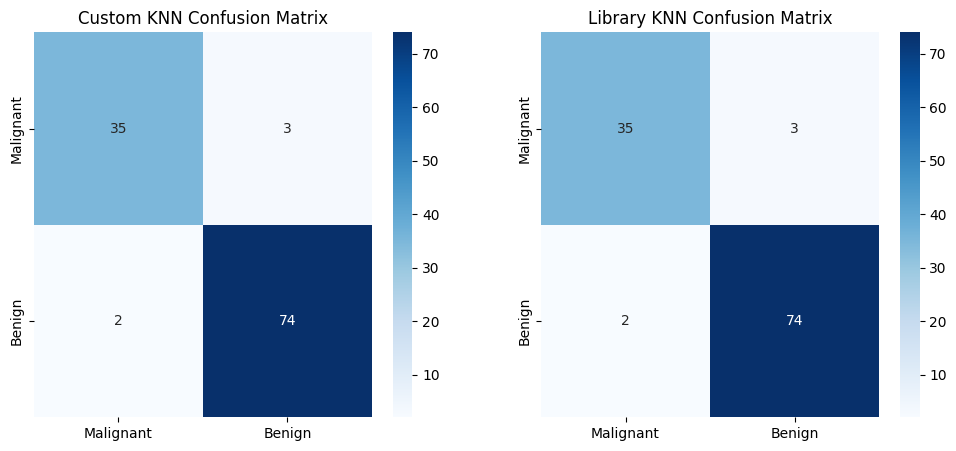

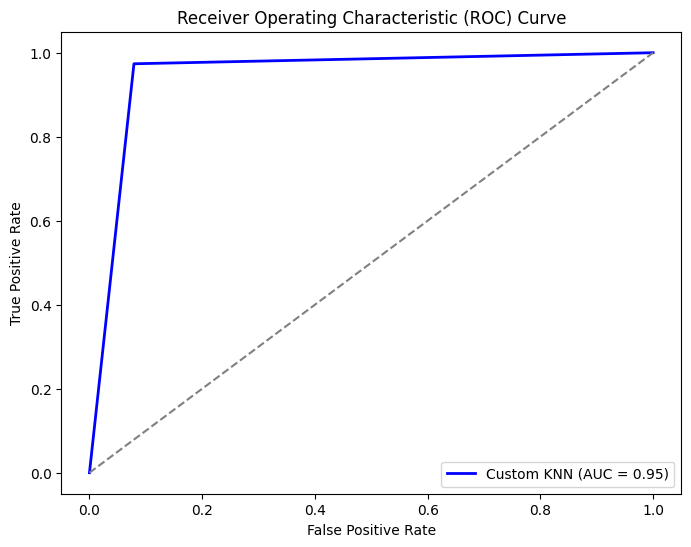

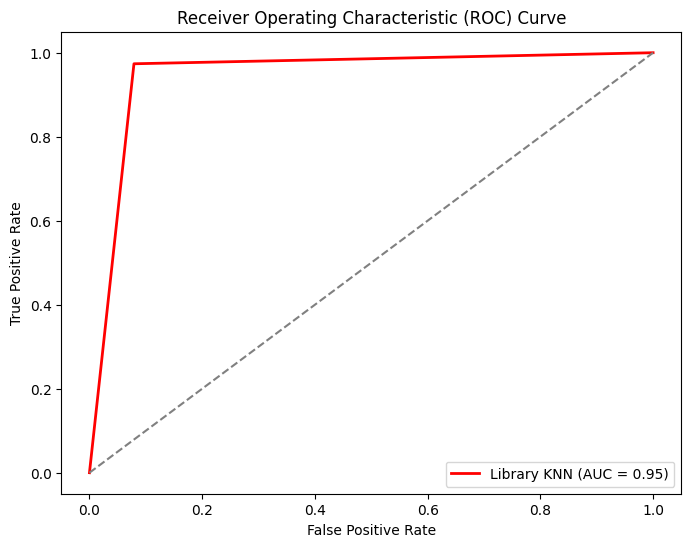

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix,roc_curve,auc
import seaborn as sns

knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X_train,y_train)
y_pred_lib = knn.predict(X_test)
#  the custom KNN model
knn_custom = KNNcustom(k=10)
knn_custom.fit(X_train,y_train)
y_pred_custom = knn_custom.predict(X_test)
# Confusion Matrix
cm_custom = confusion_matrix(y_test,y_pred_custom)
cm_lib = confusion_matrix(y_test,y_pred_lib)

# Plotting confusion matrix
fig,axes = plt.subplots(1,2,figsize=(12,5))

# Custom KNN Confusion Matrix
sns.heatmap(cm_custom,annot=True,fmt='d',cmap='Blues',xticklabels=['Malignant','Benign'],yticklabels=['Malignant','Benign'],ax=axes[0])
axes[0].set_title('Custom KNN Confusion Matrix')

# Library KNN Confusion Matrix
sns.heatmap(cm_lib,annot=True,fmt='d',cmap='Blues',xticklabels=['Malignant','Benign'],yticklabels=['Malignant','Benign'],ax=axes[1])
axes[1].set_title('Library KNN Confusion Matrix')

plt.show()

# ROC Curve and AUC
fpr_custom,tpr_custom,_ = roc_curve(y_test,y_pred_custom)
fpr_lib,tpr_lib,_ = roc_curve(y_test,y_pred_lib)

roc_auc_custom = auc(fpr_custom,tpr_custom)
roc_auc_lib = auc(fpr_lib,tpr_lib)

# Plot ROC curve
plt.figure(figsize=(8,6))
plt.plot(fpr_custom,tpr_custom,color='blue',lw=2,label=f'Custom KNN (AUC = {roc_auc_custom:.2f})')
#plt.plot(fpr_lib,tpr_lib,color='red',lw=2,label=f'Library KNN (AUC = {roc_auc_lib:.2f})')
plt.plot([0,1],[0,1],color='gray',linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()
# Plot ROC curve
plt.figure(figsize=(8,6))
#plt.plot(fpr_custom,tpr_custom,color='blue',lw=2,label=f'Custom KNN (AUC = {roc_auc_custom:.2f})')
plt.plot(fpr_lib,tpr_lib,color='red',lw=2,label=f'Library KNN (AUC = {roc_auc_lib:.2f})')
plt.plot([0,1],[0,1],color='gray',linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

#### Conclusion


#### Saving model(future use)

In [7]:
import joblib  # Import joblib to save the model

# Saving the Custom Model
joblib.dump(KNNcustom, "custom_knn_model.pkl")


print("Models saved successfully!")

Models saved successfully!
